In [210]:
# !pip install koreanize_matplotlib

import warnings
import koreanize_matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import plotly.express as px
import plotly.graph_objects as go
import ast

# 경고 무시
warnings.filterwarnings("ignore")
%config lnlineBackend.figure_format = 'retina'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)  # 출력할 너비를 넉넉하게 조정
pd.set_option('display.expand_frame_repr', False)  # 옆으로 길어져도 줄바꿈 없이 출력
pd.set_option('display.max_colwidth', None)  # 긴 문자열도 생략 없이 출력

try:
	from google.colab import drive
	drive.mount('/content/drive')

	import os
	os.chdir('/content/drive/MyDrive/파트4')
	print('✅ Succesful access google_drive_directory')
	   
except Exception as e:
	print('🤗 Hello vscode')

🤗 Hello vscode


In [211]:
API_KEY_PATH ='/home/project_yujin/API_KEY/sprintda03-yujin.json'

## get_df 함수
def get_df(db_name, table_name):
    if table_name in ['accounts_user', 'accounts_blockrecord']:
        table_name = pd.read_parquet(
            f"gs://high_project/{db_name}/{table_name}.parquet", 
            storage_options={'token' : API_KEY_PATH})
    else:
        table_name = pd.read_csv(
            f"gs://high_project/{db_name}/{table_name}.csv",
            storage_options={'token' : API_KEY_PATH}
            )
    return table_name
    

## literal_eval 형변환 함수
import ast
def to_literal_eval(df, column):
    return  df[column].apply(lambda x: ast.literal_eval(x) if x != '[]' else [])


drop_users = [831956, 1580627, 1580689, 1580626, 995177]
drop_schools = [5948, 5949, 5964]

# 리스트 내에 드랍 유저가 있는지 확인하는 함수
def find_drop_users(df, column):
    drop_users = [831956, 1580627, 1580689, 1580626, 995177]
    for i in drop_users:
        count_drop_rows = len(df[df[column].apply(lambda x: i in x)])
        if count_drop_rows != 0:
            print(f"‼️ 관리자 {i}가 포함된 행 {count_drop_rows}개 존재")
        else:
            print(f"✅ 관리자 {i} 포함행 없음")

# 1) accounts_user

In [206]:
accounts_user = get_df('votes','accounts_user')

In [207]:
accounts_user.head(1)

,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,831956,1,1,None,600,"[1292473, 913158, 1488461, 1064695, 1043565, 1274736]",0,2023-03-29 03:44:14.047130,[],[],N,0,0,0,0,NaN


In [208]:
# 관리자 제거
drop_users = [831956, 1580627, 1580689, 1580626, 995177]
accounts_user = accounts_user[~accounts_user['id'].isin(drop_users)]

# 관리자 관련 컬럼 제거
accounts_user = accounts_user.drop(columns=['is_superuser', 'is_staff'])

In [209]:
# 유저별 친구수, 차단친구수, 숨김친구수 컬럼 추가하기

# 1. 리스트형으로 변환
accounts_user['friend_id_list'] = to_literal_eval(accounts_user, 'friend_id_list')
accounts_user['block_user_id_list'] = to_literal_eval(accounts_user, 'block_user_id_list')
accounts_user['hide_user_id_list'] = to_literal_eval(accounts_user, 'hide_user_id_list')

KeyboardInterrupt: 

In [ ]:
# 2. 리스트내 관리자가 있는지 확인
find_drop_users(accounts_user, 'friend_id_list')

‼️ 관리자 831956가 포함된 행 6개 존재
✅ 관리자 1580627 포함행 없음
✅ 관리자 1580689 포함행 없음
✅ 관리자 1580626 포함행 없음
✅ 관리자 995177 포함행 없음


In [ ]:
find_drop_users(accounts_user, 'block_user_id_list')

✅ 관리자 831956 포함행 없음
✅ 관리자 1580627 포함행 없음
✅ 관리자 1580689 포함행 없음
✅ 관리자 1580626 포함행 없음
✅ 관리자 995177 포함행 없음


In [97]:
find_drop_users(accounts_user, 'hide_user_id_list')

✅ 관리자 831956 포함행 없음
✅ 관리자 1580627 포함행 없음
✅ 관리자 1580689 포함행 없음
✅ 관리자 1580626 포함행 없음
✅ 관리자 995177 포함행 없음


In [98]:
# 2-1. friend_id_list에 831956 관리자가 포함되었던 행 확인
accounts_user[accounts_user['friend_id_list'].apply(lambda x: 831956 in x)]

# 관리자를 친구로 둔 유저 6명 발견 ['913158', '1043565', '1064695', '1274736', '1292473', '1488461']

,id,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
62718,913158,F,1516,"[1137152, 1273091, 1132294, 1054471, 1354504, 1131401, 913162, 1111819, 1281932, 1261962, 1136400, 913169, 1255698, 1152124, 1132309, 1156118, 913429, 1090072, 1154844, 1274269, 1090333, 1091488, 1171105, 968993, 1137443, 1365667, 1366318, 1100080, 1136307, 913588, 1037240, 1344827, 971965, 1297087, 1134787, 1353030, 1289415, 915400, 1136202, 1194957, 1132622, 1282000, 1257293, 1305300, 1130709, 1227990, 1137111, 1020120, 831956, 1316701, 1219684, 1132776, 1237998, 1327600, 912498, 927347, 1097845, 941434, 911484, 1136936, 1210811]",0,2023-05-06 12:46:08.452942,[],[],N,0,1,0,124,17907.0
183567,1043565,F,2848,"[1233408, 1062913, 1390081, 1523201, 1287696, 1274897, 1272337, 1274387, 1232407, 1225240, 1275420, 1285662, 1166887, 1479731, 1275964, 1413712, 1289299, 1400403, 1313373, 1213536, 1235561, 1294954, 1511019, 1276020, 1313910, 1235580, 905352, 1226891, 1223310, 1275534, 1221778, 1312916, 1259161, 1242778, 1232540, 1249438, 1143467, 1209004, 1228461, 1222319, 1276592, 1298609, 1225909, 1344696, 1276096, 1277121, 1274562, 1214151, 1222860, 1226961, 1312979, 1128662, 1285846, 1415382, 1209563, 1274587, 1293027, 1312998, 1223403, 1211120, 1064695, 1208574, 1123585, 1274630, 1238791, 1211656, 1224969, 1210635, 1271567, 1352981, 1498389, 1274647, 1224471, 1502999, 1128732, 1147164, 1271582, 1274143, 1486630, 1347369, 1273646, 958256, 1298745, 1240378, 1297214, 1280326, 1287497, 1220428, 1235791, 1422675, 1383252, 1274710, 1277782, 1216345, 1371488, 1275745, 1225062, 1277290, 1280369, 1278835, ...]",1,2023-05-09 11:10:10.424976,[],[975319],N,0,4,3,351,36967.0
203076,1064695,F,4331,"[1274630, 1211656, 1506697, 1226891, 1210635, 1473676, 1275534, 1272337, 1275795, 1312916, 1274647, 1502999, 973721, 1147164, 1249438, 1274143, 1226145, 1046948, 1223591, 1347369, 1143467, 1228461, 1225909, 1365943, 1359287, 1365957, 1190859, 1235791, 1413712, 938448, 831956, 1277782, 1216345, 1209563, 1078751, 1371488, 1225062, 1225702, 1273851, 1277290, 1301996, 1043565, 1272302, 1124595, 1224180, 1166581, 1247731, 1282427, 1383161, 1275898, 1274747, 875390, 1542556, 1553363, 1578211, 1578234, 1578388]",1,2023-05-09 15:47:07.159232,[],[],N,0,4,0,1,39501.0
395957,1274736,M,737,"[1257475, 1272838, 1206279, 1550343, 1350155, 998417, 1208346, 1334816, 1207329, 1219109, 1207335, 1239594, 1222186, 1213491, 975412, 1248313, 1214010, 1322045, 1224768, 1276483, 1405515, 1488461, 1198673, 1198677, 1198179, 1372261, 1260650, 1274989, 1213553, 1271924, 1268346, 1337988, 1334918, 1239177, 1319049, 1258123, 1212556, 1205901, 1218702, 1376395, 1210013, 1226397, 1315488, 1128610, 1206443, 1265325, 1235119, 1201328, 1276592, 1222319, 1067183, 1197239, 1194682, 1338042, 1198271, 1226961, 1198291, 1206484, 1212630, 1278679, 1269974, 1128662, 1249501, 1287901, 1243361, 1201385, 1210094, 1206517, 1199863, 1393912, 1224442, 1218302, 1224969, 1210635, 1256719, 1397526, 1212695, 1240857, 1271582, 1244449, 1217326, 1259822, 1233723, 1211202, 1268035, 1197387, 1217356, 1283932, 1280861, 1197930, 1219443, 1304435, 1258869, 1351543, 1227128, 1207164, 1212286, 1233285, 867730, 1218968, ...]",1,2023-05-15 01:01:48.077415,[],[],N,0,2,0,54,53119.0
412124,1292473,F,612,"[1070795, 831956, 1046540]",1,2023-05-15 13:02:31.862945,[],[],N,0,1,0,1,62370.0
589256,1488461,M,1675,"[1469312, 1477152, 1471395, 1402531, 1351096, 1456734, 1488682, 1488433, 1286104, 1481818, 1488475, 1469406, 1276096, 1275745, 1449512, 1271787, 1361006, 1274736, 1289299, 831956, 1128662, 1275420, 870175, 1504125, 1504216, 1531456, 1551280, 1578388]",1,2023-05-24 08:00:07.083856,[],[1368047],N,0,2,0,5,76180.0


In [99]:
# 2-2. 관리자가 친구인 행을 삭제 vs 친구리스트에서 관리자 아이디만 삭제

# - 관리자가 친구인 행을 삭제
drop_index = accounts_user[accounts_user['friend_id_list'].apply(lambda x: 831956 in x)].index.tolist()
accounts_user.drop(index=drop_index)

# - 친구리스트에서 관리자 아이디만 삭제
def delete_drop_user(df, column, drop_user):
    return df[[column]].apply(lambda x: [i for i in x if i != drop_user])

delete_drop_user(accounts_user, 'friend_id_list', 831956)

# 임의 채택 친구리스트에서 관리자 아이디만 삭제
accounts_user['friend_id_list'] = delete_drop_user(accounts_user, 'friend_id_list', 831956)

In [100]:
# 유저별 친구수, 차단유저수, 숨김유저수 
accounts_user['count_friends'] = accounts_user['friend_id_list'].apply(len)
accounts_user['count_block_users'] = accounts_user['block_user_id_list'].apply(len)
accounts_user['count_hide_users'] = accounts_user['hide_user_id_list'].apply(len)

In [ ]:
# 임의 리스트 삭제 
accounts_user = accounts_user.drop(columns=['friend_id_list', 'block_user_id_list', 'hide_user_id_list'])

**유저 코호트 분석**
- 코호트를 나누는 기준은?
    - 친구수, 알람수에 따른 인기유저코호트 vs 비인기유저코호트
    - 가입 시기에 따른 코호트
    - 학교별 코호트

- 코호트를 나누어서 볼것은?
    - 유지율
    - 이탈률

- 코호트 분석을 통해 알고 싶은것
    - 친구간의 네트워크가 유지율, 이탈율에 영향을 줄지 => 네트워크가 이탈율과 유지율에 영양을 준다면 네트워크가 원할하게 될수있는 서비스 추가하기
    - ~~가입 시기가 유지율 이탈율에 영향을 줄지 => 유지율이 높았던 가입시기의 코호트에 어떤 마케팅을 했었는지 => 알수는 없음..~~
    - 학교의 위치(서울시 vs 제주시)가 유지율과 이탈율에 영향을 줄지 즉 유저가 사는 환경또는 문화가 서비스에 영향을 줄지 => 마케팅

# 2) accounts_blockrecord

In [102]:
accounts_blockrecord = get_df('votes', 'accounts_blockrecord')

In [103]:
# 컬럼 순서 정리
accounts_blockrecord = accounts_blockrecord[['id', 'user_id', 'block_user_id', 'reason', 'created_at']]

# 시간타입 형변환
accounts_blockrecord['created_at'] = pd.to_datetime(accounts_blockrecord['created_at'])

# ‼️ 중복치 제거
accounts_blockrecord = accounts_blockrecord.loc[:, 'user_id':].drop_duplicates()

# ‼️ 관리자 유저 필터링
accounts_blockrecord = accounts_blockrecord[~accounts_blockrecord['user_id'].isin([831956, 1580627, 1580689, 1580626, 995177])]

# head
accounts_blockrecord.head()

,user_id,block_user_id,reason,created_at
0,878476,867483,그냥...,2023-05-04 23:01:53
1,867564,867190,친구 사이가 어색해짐,2023-05-05 01:17:08
2,875261,875110,나랑 관련 없는 질문을 자꾸 보냄,2023-05-05 01:50:55
3,883511,883696,그냥...,2023-05-05 05:21:52
4,870177,871349,그냥...,2023-05-05 06:40:34


In [104]:
accounts_blockrecord['reason'].unique()

array(['그냥...', '친구 사이가 어색해짐', '나랑 관련 없는 질문을 자꾸 보냄', '기타', '모르는 사람임',
       '너무 많은 양의 질문을 보냄', '사칭 계정'], dtype=object)

In [105]:
# 총 차단받은 수
count_total_blocked = accounts_blockrecord['block_user_id'].value_counts().reset_index()
count_total_blocked.columns = ['block_user_id', 'total_blocked']

# 모르는 사람으로 차단받은 수
count_blocked_by_stranger = accounts_blockrecord.query('reason == "모르는 사람임"')['block_user_id'].value_counts().reset_index()
count_blocked_by_stranger.columns = ['block_user_id', 'blocked_by_stranger']

# 사칭 계정으로 차단받은 수
count_blocked_by_imposter = accounts_blockrecord.query('reason == "사칭 계정"')['block_user_id'].value_counts().reset_index()
count_blocked_by_imposter.columns = ['block_user_id', 'blocked_by_imposter']

# 너무 많은 질문으로 차단받은 수
count_blocked_by_many_question = accounts_blockrecord.query("reason == '너무 많은 양의 질문을 보냄'")['block_user_id'].value_counts().reset_index()
count_blocked_by_many_question.columns = ['block_user_id', 'blocked_by_many_questions']

# 나랑 관련 없는 질문으로 차단받은 수
count_blocked_by_no_related_question = accounts_blockrecord.query("reason == '나랑 관련 없는 질문을 자꾸 보냄'")['block_user_id'].value_counts().reset_index()
count_blocked_by_no_related_question.columns = ['block_user_id', 'blocked_by_irrelevant_questions']

# 친구 사이가 어색해져서 차단받은 수
count_blocked_by_awkward = accounts_blockrecord.query("reason == '친구 사이가 어색해짐'")['block_user_id'].value_counts().reset_index()
count_blocked_by_awkward.columns = ['block_user_id', 'blocked_by_awkward_relationship']

# 기타
count_blocked_by_other = accounts_blockrecord.query("reason == '기타'")['block_user_id'].value_counts().reset_index()
count_blocked_by_other.columns = ['block_user_id', 'blocked_by_other']

# 그냥
count_blocked_by_just = accounts_blockrecord.query("reason == '그냥...'")['block_user_id'].value_counts().reset_index()
count_blocked_by_just.columns = ['block_user_id', 'blocked_by_just']

In [106]:
# 병합
merged_counts = count_total_blocked
merged_counts = pd.merge(merged_counts, count_blocked_by_stranger, how='outer', on='block_user_id')
merged_counts = pd.merge(merged_counts, count_blocked_by_imposter, how='outer', on='block_user_id')
merged_counts = pd.merge(merged_counts, count_blocked_by_many_question, how='outer', on='block_user_id')
merged_counts = pd.merge(merged_counts, count_blocked_by_no_related_question, how='outer', on='block_user_id')
merged_counts = pd.merge(merged_counts, count_blocked_by_awkward, how='outer', on='block_user_id')
merged_counts = pd.merge(merged_counts, count_blocked_by_other, how='outer', on='block_user_id')
merged_counts = pd.merge(merged_counts, count_blocked_by_just, how='outer', on='block_user_id')
merged_counts = merged_counts.fillna(0)

In [107]:
merged_counts

,block_user_id,total_blocked,blocked_by_stranger,blocked_by_imposter,blocked_by_many_questions,blocked_by_irrelevant_questions,blocked_by_awkward_relationship,blocked_by_other,blocked_by_just
0,898020,76,25.0,4.0,18.0,23.0,6.0,0.0,0.0
1,1380465,25,21.0,2.0,0.0,0.0,2.0,0.0,0.0
2,897681,25,18.0,0.0,5.0,2.0,0.0,0.0,0.0
3,877266,25,25.0,0.0,0.0,0.0,0.0,0.0,0.0
4,876207,24,2.0,0.0,18.0,3.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
16235,1357421,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0
16236,844076,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
16237,1222669,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
16238,1370385,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [108]:
merged_counts.columns

Index(['block_user_id', 'total_blocked', 'blocked_by_stranger', 'blocked_by_imposter', 'blocked_by_many_questions', 'blocked_by_irrelevant_questions', 'blocked_by_awkward_relationship', 'blocked_by_other', 'blocked_by_just'], dtype='object')

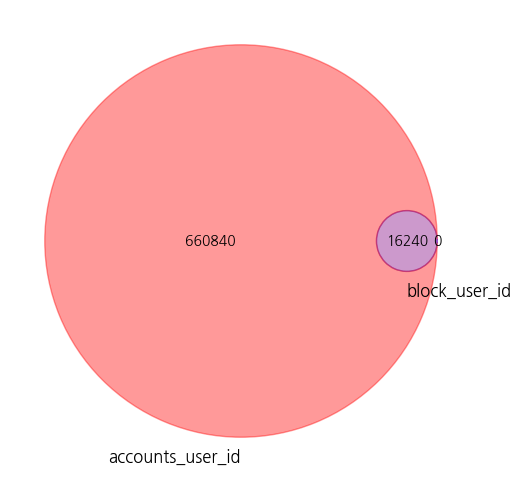

In [109]:
accounts_user_id = set(accounts_user['id'].tolist()) 
block_user_id = set(merged_counts['block_user_id'])

# 벤 다이어그램 그리기
plt.figure(figsize=(6,6))
venn = venn2([accounts_user_id, block_user_id], ('accounts_user_id', 'block_user_id'))

# 색상 설정 (파스텔 톤)
venn.get_patch_by_id('10').set_color('red')  # 빨간색
venn.get_patch_by_id('01').set_color('blue')  # 파란색
venn.get_patch_by_id('11').set_color('purple')  # 보라색 (교집합)

# 그래프 출력
plt.show()

In [112]:
merged_counts.head()

,block_user_id,total_blocked,blocked_by_stranger,blocked_by_imposter,blocked_by_many_questions,blocked_by_irrelevant_questions,blocked_by_awkward_relationship,blocked_by_other,blocked_by_just
0,898020,76,25.0,4.0,18.0,23.0,6.0,0.0,0.0
1,1380465,25,21.0,2.0,0.0,0.0,2.0,0.0,0.0
2,897681,25,18.0,0.0,5.0,2.0,0.0,0.0,0.0
3,877266,25,25.0,0.0,0.0,0.0,0.0,0.0,0.0
4,876207,24,2.0,0.0,18.0,3.0,1.0,0.0,0.0


In [67]:
master_temp1 = pd.merge(accounts_user, merged_counts, left_on='id', right_on='block_user_id', how='left')


In [68]:
master_temp1

,id,gender,point,is_push_on,created_at,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,count_friends,count_block_users,count_hide_users,block_user_id,total_blocked,blocked_by_stranger,blocked_by_imposter,blocked_by_many_questions,blocked_by_irrelevant_questions,blocked_by_awkward_relationship,blocked_by_other,blocked_by_just
0,831962,F,2248,1,2023-03-29 05:18:56.162368,N,253,40878,5499,110,12.0,43,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,832151,M,1519,0,2023-03-29 12:56:34.989468,N,0,37,0,47,1.0,51,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,832340,F,57,1,2023-03-29 12:56:35.020790,N,0,19,0,21,1.0,57,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,832520,M,1039,0,2023-03-29 12:56:35.049311,N,0,29,0,15,12.0,18,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,832614,M,1048,1,2023-03-29 12:56:35.064406,N,0,28,0,14,12.0,21,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 6) accounts_user_contacts

In [195]:
accounts_user_contacts = get_df('votes', 'accounts_user_contacts')


In [196]:
# 컬럼 순서 정리
accounts_user_contacts = accounts_user_contacts[['id', 'user_id', 'invite_user_id_list', 'contacts_count']]

# 리스트타입 변환
accounts_user_contacts['invite_user_id_list'] = to_literal_eval(accounts_user_contacts, 'invite_user_id_list')

# 관리자 제거
accounts_user_contacts = accounts_user_contacts[~accounts_user_contacts['user_id'].isin(drop_users)]
find_drop_users(accounts_user_contacts, 'invite_user_id_list')

✅ 관리자 831956 포함행 없음
✅ 관리자 1580627 포함행 없음
✅ 관리자 1580689 포함행 없음
✅ 관리자 1580626 포함행 없음
✅ 관리자 995177 포함행 없음


In [197]:
accounts_user_contacts['received_invite_counts'] = accounts_user_contacts['invite_user_id_list'].apply(len)
accounts_user_contacts['received_invite_counts'].value_counts().reset_index()

,received_invite_counts,count
0,0,3905
1,1,830
2,2,203
3,3,81
4,4,27
5,5,10
6,6,4
7,10,1
8,9,1
9,7,1


In [198]:
accounts_user.query('id == 1207606') # 2023-05-13 09:30:19.097215

accounts_user.query('id == 1050526') # 2023-05-09
accounts_user.query('id == 1050496') # 2023-05-09
accounts_user.query('id == 1167888') # 2023-05-12
accounts_user.query('id == 1185543') # 2023-05-12
accounts_user.query('id == 1186531') # 2023-05-12
accounts_user.query('id == 853318') # 
accounts_user.query('id == 976805') # 2023-05-07
accounts_user.query('id == 1119808') # 2023-05-11
accounts_user.query('id == 1166297') # 2023-05-12
accounts_user.query('id == 1063007') # 2023-05-09

,id,gender,point,is_push_on,created_at,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,count_friends,count_block_users,count_hide_users
201537,1063007,M,3856,1,2023-05-09 15:15:46.086010,N,0,1,0,109,6256.0,89,0,0


In [199]:
accounts_user_contacts

,id,user_id,invite_user_id_list,contacts_count,received_invite_counts
0,259,1167696,[],30,0
1,1756,863169,[],79,0
2,13742,857205,[854615],21,1
3,13754,851431,[],29,0
4,13756,855476,[849318],28,1
...,...,...,...,...,...
5058,12981327,1480714,[],7,0
5059,13391623,1506575,[],1,0
5060,14465598,1577436,[],0,0
5061,14579987,1582145,[],0,0


In [200]:
accounts_user_contacts

,id,user_id,invite_user_id_list,contacts_count,received_invite_counts
0,259,1167696,[],30,0
1,1756,863169,[],79,0
2,13742,857205,[854615],21,1
3,13754,851431,[],29,0
4,13756,855476,[849318],28,1
...,...,...,...,...,...
5058,12981327,1480714,[],7,0
5059,13391623,1506575,[],1,0
5060,14465598,1577436,[],0,0
5061,14579987,1582145,[],0,0


In [201]:
master_temp1

,id,gender,point,is_push_on,created_at,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,count_friends,count_block_users,count_hide_users,block_user_id,total_blocked,blocked_by_stranger,blocked_by_imposter,blocked_by_many_questions,blocked_by_irrelevant_questions,blocked_by_awkward_relationship,blocked_by_other,blocked_by_just
0,831962,F,2248,1,2023-03-29 05:18:56.162368,N,253,40878,5499,110,12.0,43,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,832151,M,1519,0,2023-03-29 12:56:34.989468,N,0,37,0,47,1.0,51,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,832340,F,57,1,2023-03-29 12:56:35.020790,N,0,19,0,21,1.0,57,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,832520,M,1039,0,2023-03-29 12:56:35.049311,N,0,29,0,15,12.0,18,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,832614,M,1048,1,2023-03-29 12:56:35.064406,N,0,28,0,14,12.0,21,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


AttributeError: 'NoneType' object has no attribute 'set_color'

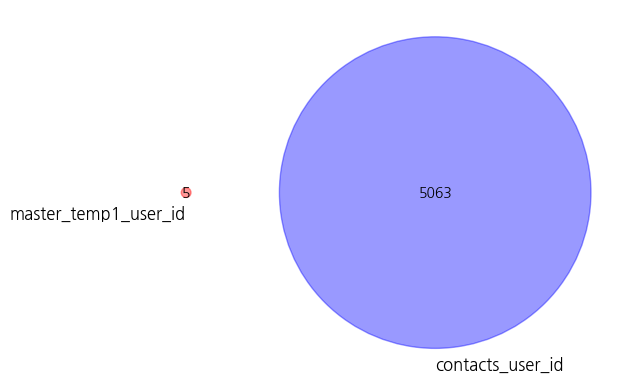

In [202]:
master_temp1_user_id = set(master_temp1['id'].tolist()) 
contacts_user_id = set(accounts_user_contacts['user_id'])

# 벤 다이어그램 그리기
plt.figure(figsize=(6,6))
venn = venn2([master_temp1_user_id, contacts_user_id], ('master_temp1_user_id', 'contacts_user_id'))

# 색상 설정 (파스텔 톤)
venn.get_patch_by_id('10').set_color('red')  # 빨간색
venn.get_patch_by_id('01').set_color('blue')  # 파란색
venn.get_patch_by_id('11').set_color('purple')  # 보라색 (교집합)

# 그래프 출력
plt.show()